#بخش اول


####سوال اول

آیا در شبکه هسته‌ای از اعضای فعال وجود دارد که بیشتر تعاملات درون آن انجام میشود(تعداد یال بیشتر )؟

آیا کاربران پرارتباط ( دوستان زیاد دارن) تمایل دارن با سایر کاربران پرارتباط‌تر در ارتباط باشن؟

####سوال دوم و تصویر های سوال چهارم (کد تصویر و نمودار)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import collections
import numpy as np


def analyze_network_structure(graph, graph_name):
    print(f"\n===== تحلیل ساختار شبکه: {graph_name} =====")

    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    average_degree = 2 * num_edges / num_nodes

    print(f"تعداد گره‌ها: {num_nodes}")
    print(f"تعداد یال‌ها: {num_edges}")
    print(f"درجه میانگین: {average_degree:.2f}")
    print("-" * 30)

    connected_components_count = nx.number_connected_components(graph)
    print(f"تعداد مولفه‌های همبند: {connected_components_count}")

    if nx.is_connected(graph):
        avg_shortest_path_length = nx.average_shortest_path_length(graph)
        print(f"میانگین طول کوتاه‌ترین مسیر: {avg_shortest_path_length:.3f}")
    else:
        largest_component = max(nx.connected_components(graph), key=len)
        graph_lcc = graph.subgraph(largest_component)
        avg_shortest_path_length_lcc = nx.average_shortest_path_length(graph_lcc)
        print(f"میانگین طول کوتاه‌ترین مسیر روی بزرگترین مولفه همبند: {avg_shortest_path_length_lcc:.3f}")


    average_clustering_coefficient = nx.average_clustering(graph)
    print(f"ضریب خوشه‌بندی میانگین: {average_clustering_coefficient:.4f}")

    degree_assortativity = nx.degree_assortativity_coefficient(graph)
    print(f"ضریب همبستگی درجه: {degree_assortativity:.4f}")

    if degree_assortativity > 0.1:
        print("تفسیر: شبکه همبستگی درجه مثبت دارد (گروه‌های پرارتباط با هم ارتباط دارند).")
    elif degree_assortativity < -0.1:
        print("تفسیر: شبکه همبستگی درجه منفی دارد (گروه‌های پرارتباط بیشتر با کم‌ارتباط‌ها ارتباط دارند).")
    else:
        print("تفسیر: شبکه همبستگی درجه خنثی دارد.")
    print("-" * 30)


    degrees = sorted([degree for node, degree in graph.degree()], reverse=True)
    degree_counts_dict = collections.Counter(degrees)
    degrees_list, counts_list = zip(*degree_counts_dict.items())

    plt.figure(figsize=(8, 6))
    plt.loglog(degrees_list, counts_list, 'o', alpha=0.7, color='purple')
    plt.title(f"Degree distribution (logarithmic scale) for{graph_name}")
    plt.xlabel("Degree (k)")
    plt.ylabel("number of node(N_k)")
    plt.grid(True, which="both", ls="--")
    plt.show()


    plt.figure(figsize=(10, 6))
    plt.bar(degrees_list, counts_list, width=0.8, color='skyblue')
    plt.title(f"Bar chart of grade distribution for {graph_name}")
    plt.xlabel("Degree (k)")
    plt.ylabel("number of node(N_k)")
    plt.xticks(degrees_list)
    plt.grid(axis='y', linestyle='--')
    plt.show()



    if num_nodes < 100:
        plt.figure(figsize=(10, 8))
        nx.draw(graph, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray', alpha=0.8, font_size=10)
        plt.title(f"Network diagram for {graph_name}")
        plt.show()


===== تحلیل ساختار شبکه: Zachary's Karate Club =====
تعداد گره‌ها: 34
تعداد یال‌ها: 78
درجه میانگین: 4.59
------------------------------
تعداد مولفه‌های همبند: 1
میانگین طول کوتاه‌ترین مسیر: 2.408
ضریب خوشه‌بندی میانگین: 0.5706
ضریب همبستگی درجه: -0.4756
تفسیر: شبکه همبستگی درجه منفی دارد (گروه‌های پرارتباط بیشتر با کم‌ارتباط‌ها ارتباط دارند).
------------------------------


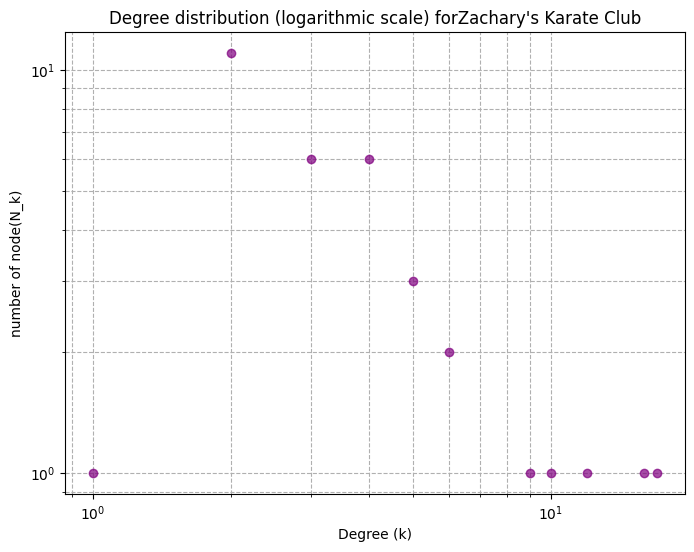

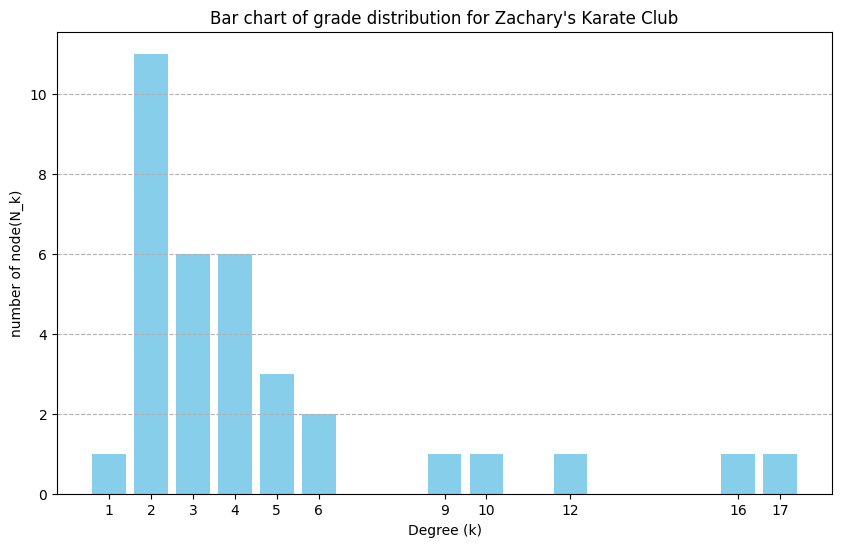

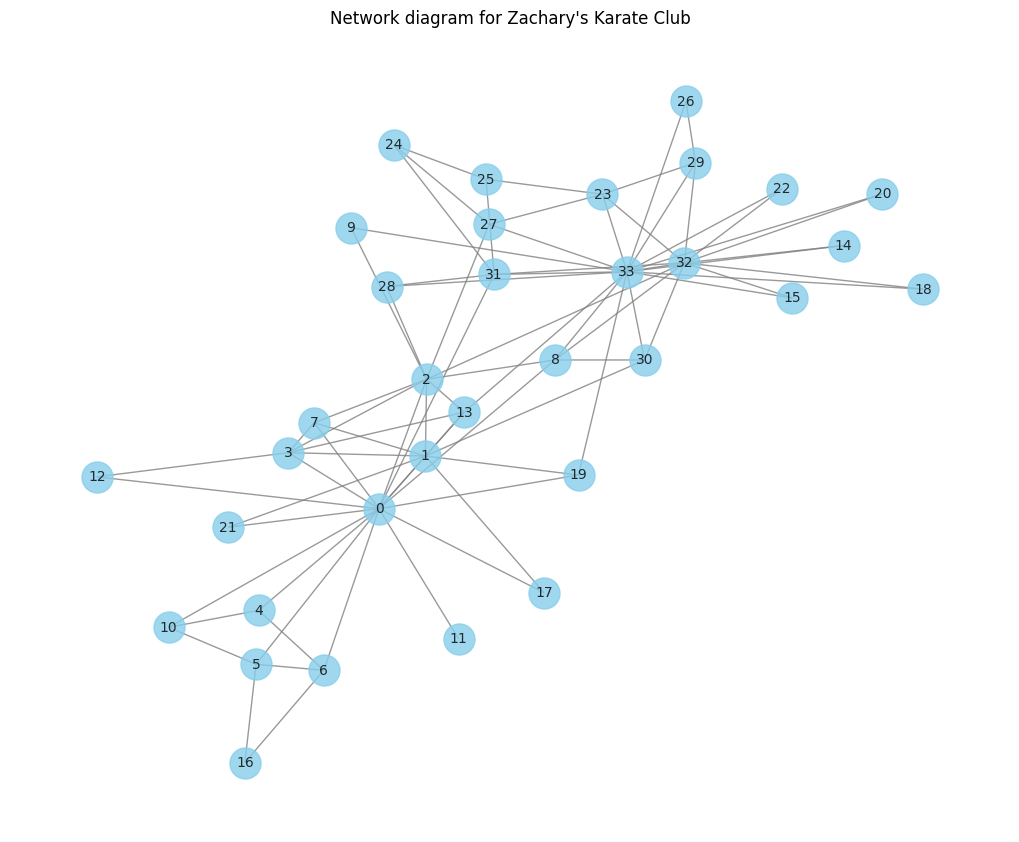

In [ ]:
G_karate = nx.karate_club_graph()
analyze_network_structure(G_karate, "Zachary's Karate Club")
print("\n" + "=" * 50 + "\n")

######گراف فیس بوک


In [ ]:
try:
    G_facebook = nx.read_edgelist("facebook_combined.txt.gz", create_using=nx.Graph(), nodetype=int)
    print("facebook dataset uploaded successfully!")
except FileNotFoundError:
    print("facebook dataset couldn't be uploaded successfully!")

facebook dataset uploaded successfully!



===== تحلیل ساختار شبکه: Facebook Social Network =====
تعداد گره‌ها: 4039
تعداد یال‌ها: 88234
درجه میانگین: 43.69
------------------------------
تعداد مولفه‌های همبند: 1
میانگین طول کوتاه‌ترین مسیر: 3.693
ضریب خوشه‌بندی میانگین: 0.6055
ضریب همبستگی درجه: 0.0636
تفسیر: شبکه همبستگی درجه خنثی دارد.
------------------------------


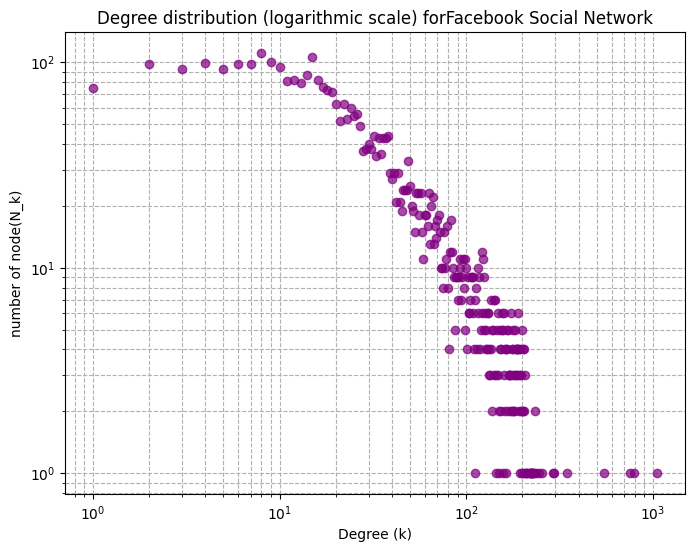

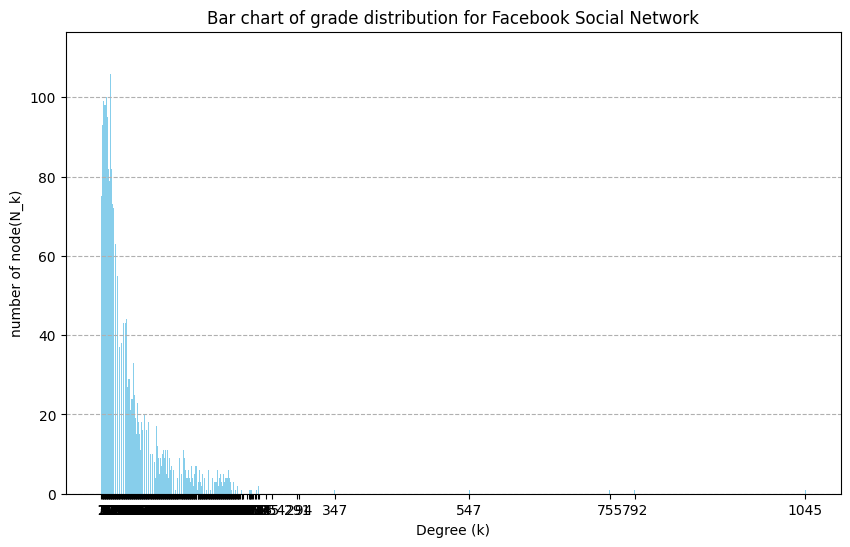

In [ ]:
analyze_network_structure(G_facebook, "Facebook Social Network")

####سوال سوم

## Facebook Dataset

| شاخص                  | هدف انتخاب                                         | انتظار پیش از تحلیل                                                     |
| :-------------------- | :------------------------------------------------- | :---------------------------------------------------------------------- |
| توزیع درجه            | بررسی ساختار اتصالات و وجود کاربران پرارتباط  | توزیع قانون توان (چند کاربر با دوستان زیاد، بیشتر کاربران با دوستان کم) |
| ضریب خوشه‌بندی        | سنجش تمایل دوستان به آشنایی متقابل                 | بالا (گروه‌های خانوادگی، تحصیلی، کاری)                                  |
| طول مسیر میانگین      | بررسی خاصیت دنیای کوچک                             | کوتاه (حدود ۳–۵ گام بین هر دو کاربر)                                    |
| همبستگی درجه          | بررسی ارتباط بین کاربران مشابه از نظر فعالیتهاشون       | مثبت (کاربران فعال با کاربران فعال دیگر ارتباط دارند)                   |
| تعداد مؤلفه‌های همبند | سنجش انسجام کل  شبکه امون                                | یک مؤلفه‌ی بزرگ و چند مؤلفه‌ی کوچک کپسوله شده                               |

***


## Zachary's Karate Club

| شاخص             | هدف انتخاب                           | انتظار پیش از تحلیل                                            |
| :--------------- | :----------------------------------- | :------------------------------------------------------------- |
| توزیع درجه       | پیدا کردن ساختار ارتباطی و گره‌های کلیدی | چند گره با درجه بالا (اساتید) و بسیاری با درجه پایین (شاگردان) |
| ضریب خوشه‌بندی   | فهمیدن تمایل به تشکیل گروه‌ها          | نسبتاً بالا (چون اعضا در گروه‌های تمرینی هستند)                |
| طول مسیر میانگین | بررسی خاصیت دنیای کوچک               | کم (دو سه تا گام)                                                |
| همبستگی درجه     | بررسی نوع ارتباط بین گره‌ های مشابه   | احتمالا منفی یا نزدیک صفر                                     |
| تعداد مولفه‌ها   | بررسی انسجام شبکه                    | احتمالا ۱ مولفه‌ی همبند                                       |




***

####سوال پنجم


<div dir="rtl" style="text-align: right;">


## تحلیل نتایج شبکه

با توجه به اجرای تابع analyze_network_structure بر روی شبکه‌های Zacharys Karate Club و Facebook، نتایج زیر بدست اومد و با انتظارات اولیه مقایسه میشه:

### Zacharys Karate Club (شبکه کوچک)

*   **توزیع درجه:** نمودار توزیع درجه به مقیاس لگاریتمی و نمودار میله‌ای نشون میده که تعداد گره‌هایی با درجه پایین بیشتره و چند گره (احتمالا رهبران باشگاه) دارای درجه بسیار بالاتری هستن. این مطابق با انتظار وجود چند گره کلیدی (اساتید) و تعداد زیادی گره با درجه پایین‌تر (شاگردان) بود
*   **ضریب خوشه‌بندی میانگین :** مقدار محاسبه شده ( 0.57تقریبا) نسبتا بالاست. این مطابق با انتظار بالا بودن ضریب خوشه‌بندی در یک گروه اجتماعی کوچک با تمایل به آشنایی متقابل بین اعضاست و نشان‌دهنده وجود خوشه‌ها و زیرگروه‌ها در باشگاه
*   **میانگین طول مسیر :** مقدار محاسبه شده (تقریبا 2.41) بسیار کوتاهه. این کاملا مطابق انتظار کوتاه بودن طول مسیر در یک شبکه کوچک و تأیید ویژگی دنیای کوچک برای این شبکه هستش
*   **تعداد مؤلفه‌های همبند:** تعداد مؤلفه‌های همبند برابر با 1 است این منطبقه بر  انتظار پیوستگی شبکه اصلی باشگاه قبل از انشعاب
*   **همبستگی درجه :** ضریب همبستگی درجه (-0.48) منفی است. این برخلاف انتظار اولیه مثبت بودن بود تفسیر این نتیجه منفی اینه که گره‌های پرارتباط (با درجه بالا) میخواهند بیشتر با گره‌های کم‌ارتباط (با درجه پایین) در ارتباط باشند تا با گره‌های پرارتباط دیگر. این یعنی  ساختار سلسله‌ مراتبی یا نقش‌های متفاوت اساتید (که با همه در ارتباطند)و اعضای عادی  

### Facebook Social Network (شبکه بزرگ)

*   **توزیع درجه (Log-Log Plot):** نمودار توزیع درجه به مقیاس لگاریتمی نشون دهنده توزیعی با دم سنگین (Heavy-tailed) هست    این   مطابق با انتظار توزیع قانون توان (Scale-Free) برای شبکه‌های اجتماعی بزرگخ که نشان مبده تعداد کمی کاربر با تعداد بسیار زیادی دوست  و تعداد زیادی کاربر با دوستان کمتر وجود دارن
*   **میانگین طول مسیر :** مقدار محاسبه شده ( 3.69) بسیار کوتاه هست این  مطابق با انتظار کوتاه بودن طول مسیر در شبکه‌های اجتماعی بزرگ و تأیید قوی پدیده دنیای کوچک  برای این شبکه هستش
*   **ضریب خوشه‌بندی میانگین :** مقدار محاسبه شده ( 0.61) بالا است. این مطابق با انتظار بالا بودن ضریب خوشه‌بندی در شبکه‌های اجتماعی و نشان‌دهنده وجود گروه‌ها و جوامع محلی (مثلا خونواده) در فیس‌بوک است.

*   **همبستگی درجه :** ضریب همبستگی درجه ( 0.06) نزدیک صفره و    این  مطابق انتظار مثبت بودن بود، اما مقدار آن کمتر از حد انتظار برای یک شبکه همگن بود. تفسیر  این که در شبکه فیس‌بوک، تمایل به همبستگی درجه مثبت وجود داره (کاربران پرارتباط تا حدی با هم ارتباط دارند)، اما این تمایل قوی نیست و شبکه تقریباً خنثی رفتار می‌کند

**نتیجه‌گیری کلی:**

تحلیل‌ها بسیاری از ویژگی‌های مورد انتظار شبکه‌های اجتماعی کوچک و بزرگ را تایید کردند از جمله پدیده دنیای کوچک خوشه‌بندی بالا و توزیع درجه ناهمگن مهمترین نتیجه غیرمنتظره در شبکه Zacharys Karate Club همبستگی درجه منفی بود که چالشی در مورد ساختار ارتباطی داخلی آن ارائه میدهد در شبکه فیس‌بوک همبستگی درجه کمتر از حد انتظار قوی بود که میتونه به دلیل ماهیت متفاوت ارتباطات در یک پلتفرم اجتماعی بزرگ باشد

</div>


#بخش دوم


####سوال اول


Creating the Random and Small-world graph models with Facebook parameters and plotting their network diagrams.

Created an Erdos-Rényi Random Graph with 4039 nodes and 88234 edges.
Created a Watts-Strogatz Small-world Graph with 4039 nodes and 88858 edges (approx. average degree 44.00).


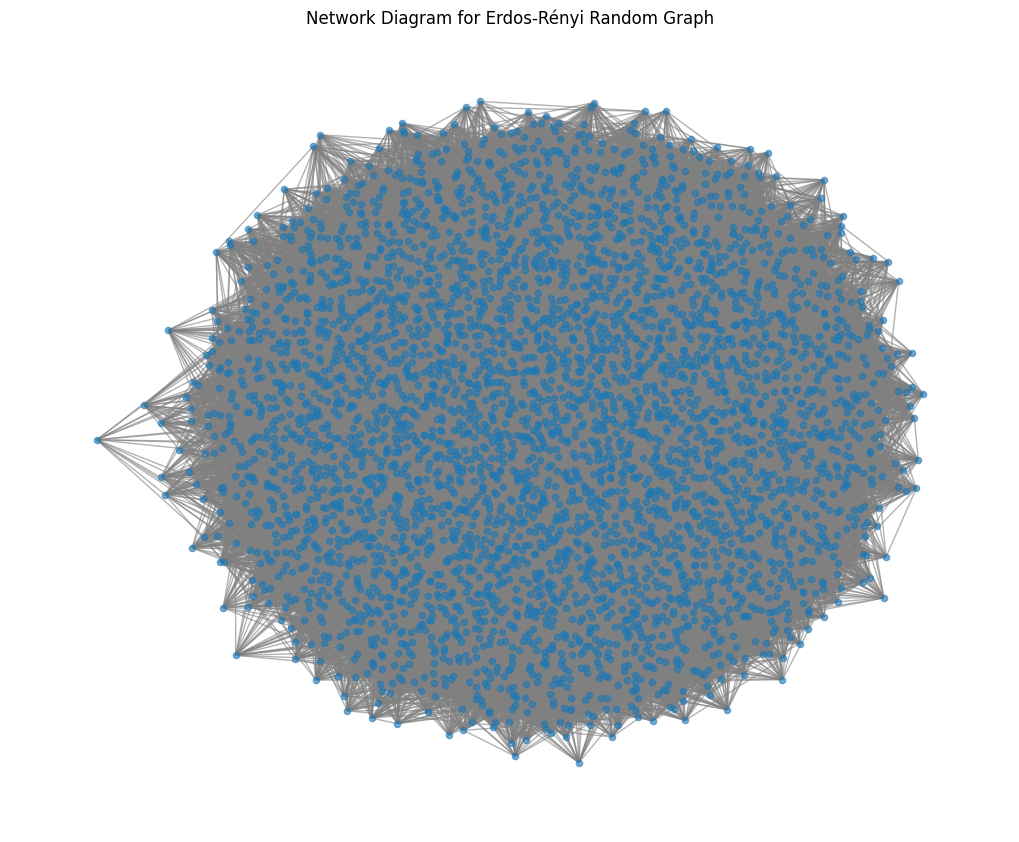

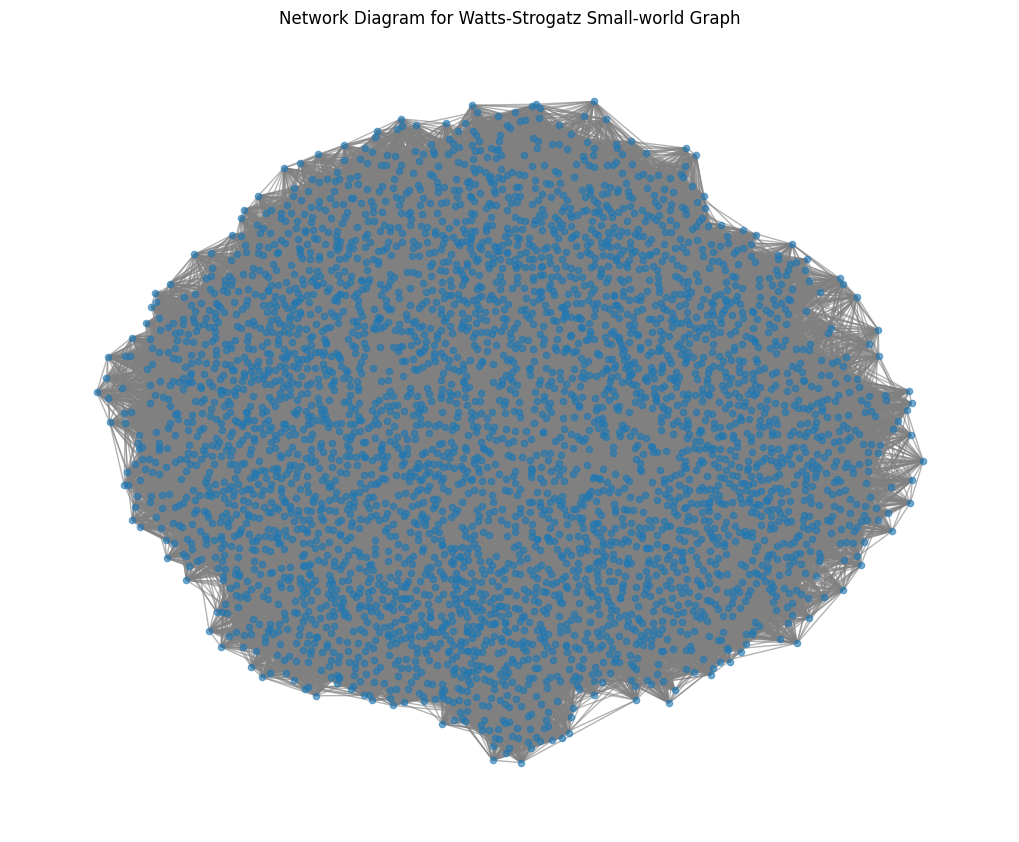

In [ ]:
n = G_facebook.number_of_nodes()
m = G_facebook.number_of_edges()
G_er = nx.gnm_random_graph(n, m)

avg_degree_facebook = 2 * G_facebook.number_of_edges() / G_facebook.number_of_nodes()

k = int(round(avg_degree_facebook))
if k % 2 != 0:
    k += 1
if k == 0:
    k = 2

p = 0.1

if k >= n:
    k = n - 1
    if k % 2 != 0:
        k -= 1
    if k < 1:
        k = 1

G_ws = nx.watts_strogatz_graph(n, k, p)

print(f"Created an Erdos-Rényi Random Graph with {G_er.number_of_nodes()} nodes and {G_er.number_of_edges()} edges.")
print(f"Created a Watts-Strogatz Small-world Graph with {G_ws.number_of_nodes()} nodes and {G_ws.number_of_edges()} edges (approx. average degree {2 * G_ws.number_of_edges() / G_ws.number_of_nodes():.2f}).")

plt.figure(figsize=(10, 8))
nx.draw(G_er, with_labels=False, node_size=20, edge_color='gray', alpha=0.6)
plt.title("Network Diagram for Erdos-Rényi Random Graph")
plt.show()

plt.figure(figsize=(10, 8))
nx.draw(G_ws, with_labels=False, node_size=20, edge_color='gray', alpha=0.6)
plt.title("Network Diagram for Watts-Strogatz Small-world Graph")
plt.show()

####سوال دوم


In [ ]:

print("\n--- تحلیل گراف تصادفی Erdos-Rényi ---")
avg_clustering_er = nx.average_clustering(G_er)

if nx.is_connected(G_er):
    avg_shortest_path_er = nx.average_shortest_path_length(G_er)
    print(f"میانگین طول کوتاه‌ترین مسیر: {avg_shortest_path_er:.3f}")
else:
    print("گراف تصادفی همبند نیست، محاسبه میانگین طول مسیر روی بزرگترین مولفه همبند:")
    largest_component_er = max(nx.connected_components(G_er), key=len)
    graph_lcc_er = G_er.subgraph(largest_component_er)
    avg_shortest_path_er = nx.average_shortest_path_length(graph_lcc_er)
    print(f"میانگین طول کوتاه‌ترین مسیر (مولفه بزرگ): {avg_shortest_path_er:.3f}")


degrees_er = [degree for node, degree in G_er.degree()]
degree_counts_er = collections.Counter(degrees_er)
print(f"ضریب خوشه‌بندی میانگین: {avg_clustering_er:.4f}")
print(f"نمونه‌ای از توزیع درجه (چند درجه پرتکرار): {degree_counts_er.most_common(5)}")


print("\n--- تحلیل گراف جهان کوچک Watts-Strogatz ---")
avg_clustering_ws = nx.average_clustering(G_ws)
if nx.is_connected(G_ws):
    avg_shortest_path_ws = nx.average_shortest_path_length(G_ws)
    print(f"میانگین طول کوتاه‌ترین مسیر: {avg_shortest_path_ws:.3f}")
else:
    print("گراف جهان کوچک همبند نیست، محاسبه میانگین طول مسیر روی بزرگترین مولفه همبند:")
    largest_component_ws = max(nx.connected_components(G_ws), key=len)
    graph_lcc_ws = G_ws.subgraph(largest_component_ws)
    avg_shortest_path_ws = nx.average_shortest_path_length(graph_lcc_ws)
    print(f"میانگین طول کوتاه‌ترین مسیر (مولفه بزرگ): {avg_shortest_path_ws:.3f}")


degrees_ws = [degree for node, degree in G_ws.degree()]
degree_counts_ws = collections.Counter(degrees_ws)
print(f"ضریب خوشه‌بندی میانگین: {avg_clustering_ws:.4f}")
print(f"نمونه‌ای از توزیع درجه (چند درجه پرتکرار): {degree_counts_ws.most_common(5)}")


--- تحلیل گراف تصادفی Erdos-Rényi ---
میانگین طول کوتاه‌ترین مسیر: 2.606
ضریب خوشه‌بندی میانگین: 0.0107
نمونه‌ای از توزیع درجه (چند درجه پرتکرار): [(44, 250), (45, 249), (42, 237), (46, 227), (41, 218)]

--- تحلیل گراف جهان کوچک Watts-Strogatz ---
میانگین طول کوتاه‌ترین مسیر: 2.966
ضریب خوشه‌بندی میانگین: 0.5363
نمونه‌ای از توزیع درجه (چند درجه پرتکرار): [(44, 820), (43, 716), (45, 696), (42, 493), (46, 476)]


####سوال سوم


In [ ]:
n = G_facebook.number_of_nodes()
m = G_facebook.number_of_edges()
p_values_to_test = [0.005, 0.01, 0.012, 0.015, 0.02]
results = {}
for p in p_values_to_test:
    print(f"\nساخت گراف Erdos-Rényi با p = {p}")
    G_er_test = nx.erdos_renyi_graph(n, p)
    num_nodes_test = G_er_test.number_of_nodes()
    num_edges_test = G_er_test.number_of_edges()
    avg_clustering_test = nx.average_clustering(G_er_test)
    avg_shortest_path_test = None
    largest_component_test = max(nx.connected_components(G_er_test), key=len)
    if largest_component_test and len(largest_component_test) > 1:
         graph_lcc_test = G_er_test.subgraph(largest_component_test)
         avg_shortest_path_test = nx.average_shortest_path_length(graph_lcc_test)

    print(f"  تعداد گره‌ها: {num_nodes_test}")
    print(f"  تعداد یال‌ها: {num_edges_test}")
    print(f"  ضریب خوشه‌بندی میانگین: {avg_clustering_test:.4f}")

    print(f"  میانگین طول کوتاه‌ترین مسیر: {avg_shortest_path_test:.3f}")

    print("  توزیع درجه: انتظار می‌رود که از توزیع پواسون پیروی کند.")
    results[p] = {
        "num_edges": num_edges_test,
        "avg_clustering": avg_clustering_test,
        "avg_shortest_path": avg_shortest_path_test
    }
print("\n**خلاصه نتایج برای p های مختلف:**")
for p, data in results.items():
    print(f"p = {p:.6f}: یال‌ها = {data['num_edges']}, خوشه‌بندی = {data['avg_clustering']:.4f}, طول مسیر = {data['avg_shortest_path'] if data['avg_shortest_path'] is not None else 'N/A'}")


ساخت گراف Erdos-Rényi با p = 0.005
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 40435
  ضریب خوشه‌بندی میانگین: 0.0053
  میانگین طول کوتاه‌ترین مسیر: 3.046
  توزیع درجه: انتظار می‌رود که از توزیع پواسون پیروی کند.

ساخت گراف Erdos-Rényi با p = 0.01
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 81359
  ضریب خوشه‌بندی میانگین: 0.0100
  میانگین طول کوتاه‌ترین مسیر: 2.652
  توزیع درجه: انتظار می‌رود که از توزیع پواسون پیروی کند.

ساخت گراف Erdos-Rényi با p = 0.012
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 97854
  ضریب خوشه‌بندی میانگین: 0.0120
  میانگین طول کوتاه‌ترین مسیر: 2.540
  توزیع درجه: انتظار می‌رود که از توزیع پواسون پیروی کند.

ساخت گراف Erdos-Rényi با p = 0.015
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 122122
  ضریب خوشه‌بندی میانگین: 0.0149
  میانگین طول کوتاه‌ترین مسیر: 2.383
  توزیع درجه: انتظار می‌رود که از توزیع پواسون پیروی کند.

ساخت گراف Erdos-Rényi با p = 0.02
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 162676
  ضریب خوشه‌بندی میانگین: 0.0199
  میانگین طول کوتاه‌ترین مسیر: 2.177
  توزیع درجه: انتظار می

<div dir="rtl" style="text-align: right;">
**توضیح فرآیند انتخاب p (همون r) با مقادیر مختلف در مدل Erdos-Rényi:**

برای بررسی تأثیر پارامتر p در مدل Erdos-Rényi بر ویژگی‌های گراف و اینکه کدام p   بهتر شبکه واقعی را تقریبی کند، می‌تونیم چندین بار با p متفاوت بسازیمش

هر چقدر این احتمال بیشتر باشه منطقا گراف هم متراکم تره  و روی تعداد یال و میانگین درجه اثرگذاره

مثلا تو همین کد چندتا احتمال متقاوت میذاریم هر بار  و مقادیر رو محاسبه میکنیم

**نحوه انتخاب p برای تولید دوباره و تقریبی ویژگی‌ها:**


بر اساس معیار های مختلفی  p  رو انتخاب میکنیم


1.  **بر اساس تعداد یال‌ها یا میانگین درجه:**
برای اینکه شبیه مدلهای واقعی تر بشه شبکمون میایم طوری انتخاب میکنیم که  تعداد یال مورد نظرمون با فرمول p * n * (n-1) / 2 با تعداد یال واقعی یکی باشن تقریبا


2.  **بر اساس ضریب خوشه‌بندی:** بر اساس ضریب خوشه بندی هم میشه  فقط باید p  بزرگتر باشه تا گراف بزرگتر و متراکم تر شه

3.  **بر اساس میانگین طول مسیر:**

هر چی p  بیشتر تو اینمدل اردوش اونوقت میانگین طول مسیر هم کمتر  و اگه بر اساس تعداد یال محاسبه شه طول مسیر هم کوتاه تره

با ساخت گراف‌ها با مقادیر مختلف `p` و مقایسه نتایج با شبکه فیس‌بوک (همانطور که در خروجی کد بالا مشخص است)، مشاهده می‌کنیم که حتی با انتخاب `p` نزدیک به مقداری که تعداد یال‌ها را تطبیق می‌دهد، ضریب خوشه‌بندی مدل Erdos-Rényi بسیار پایین‌تر از شبکه واقعی باقی می‌ماند. این نشان می‌دهد که مدل Erdos-Rényi، با وجود سادگی و کوتاهی میانگین طول مسیر، در بازتولید ساختار محلی (خوشه‌بندی بالا) و توزیع درجه ناهمگن شبکه‌های اجتماعی واقعی مانند فیس‌بوک محدودیت دارد.
</div>

####سوال چهارم

In [ ]:
n = G_facebook.number_of_nodes()
avg_degree_facebook = 2 * G_facebook.number_of_edges() / G_facebook.number_of_nodes()

k = int(round(avg_degree_facebook))
if k % 2 != 0:
    k += 1
if k == 0:
    k = 2
if k >= n:
    k = n - 1
    if k % 2 != 0:
        k -= 1
    if k < 1:
        k = 1

p_values_to_test_ws = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]
print(f"تعداد گره‌ها (n): {n}")
print(f"درجه اولیه در شبکه منظم (k): {k}")
print("\n--- مقایسه ویژگی‌های گراف‌های Watts-Strogatz با p های مختلف ---")
results_ws = {}
for p in p_values_to_test_ws:
    print(f"\nساخت گراف Watts-Strogatz با p = {p:.4f}")
    G_ws_test = nx.watts_strogatz_graph(n, k, p)
    num_nodes_test = G_ws_test.number_of_nodes()
    num_edges_test = G_ws_test.number_of_edges()
    avg_clustering_test = nx.average_clustering(G_ws_test)
    avg_shortest_path_test = None
    largest_component_test = max(nx.connected_components(G_ws_test), key=len)
    graph_lcc_test = G_ws_test.subgraph(largest_component_test)
    avg_shortest_path_test = nx.average_shortest_path_length(graph_lcc_test)
    print(f"  تعداد گره‌ها: {num_nodes_test}")
    print(f"  تعداد یال‌ها: {num_edges_test}")
    print(f"  ضریب خوشه‌بندی میانگین: {avg_clustering_test:.4f}")
    print(f"  میانگین طول کوتاه‌ترین مسیر: {avg_shortest_path_test:.3f}")
    print(f"  توزیع درجه: برای p کوچک قله‌ای در k دارد، با افزایش p به پواسون نزدیک می‌شود.")
    results_ws[p] = {
        "num_edges": num_edges_test,
        "avg_clustering": avg_clustering_test,
        "avg_shortest_path": avg_shortest_path_test
    }
print("\n**خلاصه نتایج برای p های مختلف در مدل Watts-Strogatz:**")
for p, data in results_ws.items():
    print(f"p = {p:.4f}: یال‌ها (تقریبی) = {data['num_edges']}, خوشه‌بندی = {data['avg_clustering']:.4f}, طول مسیر = {data['avg_shortest_path'] if data['avg_shortest_path'] is not None else 'N/A'}")

تعداد گره‌ها (n): 4039
درجه اولیه در شبکه منظم (k): 44

--- مقایسه ویژگی‌های گراف‌های Watts-Strogatz با p های مختلف ---

ساخت گراف Watts-Strogatz با p = 0.0000
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 88858
  ضریب خوشه‌بندی میانگین: 0.7326
  میانگین طول کوتاه‌ترین مسیر: 46.387
  توزیع درجه: برای p کوچک قله‌ای در k دارد، با افزایش p به پواسون نزدیک می‌شود.

ساخت گراف Watts-Strogatz با p = 0.0010
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 88858
  ضریب خوشه‌بندی میانگین: 0.7308
  میانگین طول کوتاه‌ترین مسیر: 7.709
  توزیع درجه: برای p کوچک قله‌ای در k دارد، با افزایش p به پواسون نزدیک می‌شود.

ساخت گراف Watts-Strogatz با p = 0.0100
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 88858
  ضریب خوشه‌بندی میانگین: 0.7117
  میانگین طول کوتاه‌ترین مسیر: 4.135
  توزیع درجه: برای p کوچک قله‌ای در k دارد، با افزایش p به پواسون نزدیک می‌شود.

ساخت گراف Watts-Strogatz با p = 0.1000
  تعداد گره‌ها: 4039
  تعداد یال‌ها: 88858
  ضریب خوشه‌بندی میانگین: 0.5366
  میانگین طول کوتاه‌ترین مسیر: 2.966
  توزیع درجه: برای p کوچک ق

<div dir="rtl" style="text-align: right;">
توضیح فرآیند انتخاب p در مدل Watts-Strogatz:


این یکی مدل هم سه تا پارامتر داره n  k  p که به ترتیب تعداد نود و درجه گره در شبکه حلقوی و احتمال یال  هست  و اگه p  برابر صفر باشه یعنی شبکه منظمه و حلقوی طور وگرنه که  شبیه مدل Erdos-Rényi ولی معمولا در شبکه های جهان کوچک بزرگتر از صفر و کمتر از 0.2 هست که ضریب خوشه بندی این شبکه بالا و طول مسیر هم کوتاه تره منطقا


مراحل انتخاب احتمال پیوند Watts-Strogatz

1.  **تنظیم `n` و `k`:**
k رو تقریبا برابر میانگین درجه شبکه های واقعی میذاریم و  n رو هم تعداد نودها
مثلا اینجا k  رو گذاشتم نزدیک ترین زوج به میانگین درجه شبکه فیس بوک  که باعث میشه تعداد یال و میانگین درجه تقریبا همون شبکه اصلی بشه

2.  **تنظیم `p` (احتمال بازپیوند):** این پارامتر کلید تنظیم مدل Watts-Strogatz برای رسیدن به ویژگی‌های جهان کوچک و تطبیق با شبکه واقعی است.
    *   وقتی `p` کوچک است، بیشتر یال‌ها در جای خود باقی می‌مانند و ساختار محلی (خوشه‌بندی بالا) حفظ می‌شود. همزمان، تعداد کمی بازپیوند تصادفی "میانبرها"یی ایجاد می‌کنند که باعث کاهش سریع میانگین طول مسیر می‌شود.
    *   با افزایش `p`، شبکه بیشتر تصادفی می‌شود. ضریب خوشه‌بندی کاهش می‌یابد و میانگین طول مسیر همچنان کوتاه باقی می‌ماند (شبیه به گراف تصادفی).
    *   وقتی `p=1`، تمام یال‌ها به صورت تصادفی بازپیوند می‌شوند و گراف تقریباً یک گراف تصادفی G(n, p) با `p = k / (n-1)` خواهد بود.

3.  **آزمایش با مقادیر مختلف `p`:** برای یافتن `p` مناسب، می‌توانیم گراف‌های Watts-Strogatz را با مقادیر مختلف `p` (معمولاً در محدوده 0 تا 0.2 برای شبکه‌های جهان کوچک) بسازیم و ویژگی‌های آن‌ها (به ویژه ضریب خوشه‌بندی و میانگین طول مسیر) را محاسبه و با شبکه فیس‌بوک مقایسه کنیم.

در کد بالا، چندین مقدار مختلف برای `p` (از 0 تا 1) را آزمایش کرده‌ایم. با بررسی خروجی‌ها، می‌توانیم ببینیم که چگونه با افزایش `p`، ضریب خوشه‌بندی از مقدار بالای شبکه منظم اولیه (p=0) کاهش می‌یابد و میانگین طول مسیر به سرعت از مقدار بالای شبکه منظم کاهش یافته و به مقدار کوتاهی می‌رسد.

برای تقریبی بازتولید کردن شبکه فیس‌بوک با مدل Watts-Strogatz، هدف این است که `p`ای را پیدا کنیم که هم ضریب خوشه‌بندی و هم میانگین طول مسیر مدل Watts-Strogatz به مقادیر مشاهده شده در شبکه فیس‌بوک نزدیک شود. معمولاً مقادیر کوچک `p` در محدوده شبکه‌های جهان کوچک این دو ویژگی را بهتر از مدل کاملاً تصادفی بازتولید می‌کنند، هرچند که مدل Watts-Strogatz نیز در بازتولید توزیع درجه سنگین-دم شبکه‌های اجتماعی محدودیت دارد.
</div>

####سوال پنجم


<div dir="rtl" style="text-align: right;">
**نتیجه‌گیری: کدام مدل به شبکه فیس‌بوک نزدیک‌تر است؟**

بر اساس مقایسه ویژگی‌های آماری، مدل **جهان کوچک Watts-Strogatz** به طور کلی شباهت بیشتری به شبکه واقعی فیس‌بوک نسبت به مدل تصادفی Erdos-Rényi دارد. دلیل اصلی این امر، توانایی مدل Watts-Strogatz در بازتولید همزمان دو ویژگی کلیدی شبکه‌های واقعی است: **ضریب خوشه‌بندی بالا** و **میانگین طول مسیر کوتاه**. در حالی که مدل Erdos-Rényi میانگین طول مسیر کوتاهی دارد، ضریب خوشه‌بندی آن بسیار پایین‌تر از شبکه‌های واقعی اجتماعی است. مدل Watts-Strogatz با معرفی احتمال بازپیوند (`p`) امکان حفظ ساختار محلی و خوشه‌بندی بالا (مشابه شبکه‌های منظم) را فراهم می‌کند، در حالی که تعداد کمی بازپیوند تصادفی باعث ایجاد میانبرهایی در شبکه و کاهش سریع میانگین طول مسیر می‌شود. با این حال، باید توجه داشت که حتی مدل Watts-Strogatz نیز در بازتولید کامل **توزیع درجه سنگین-دم** مشاهده شده در شبکه فیس‌بوک (که مشخصه شبکه‌های مقیاس-آزاد با هاب‌های پرارتباط است) محدودیت دارد. بنابراین، در حالی که مدل Watts-Strogatz ویژگی‌های "جهان کوچک" و خوشه‌بندی را بهتر نشان می‌دهد، هیچ یک از مدل‌های ساده به طور کامل پیچیدگی ساختاری شبکه واقعی فیس‌بوک را پوشش نمی‌دهند.
</div>

<h1>بخش سوم</h1>

<h4>سوال اول و دوم  </h4>


Created a custom Kleinberg-like small-world graph with 100 nodes and 201 edges.


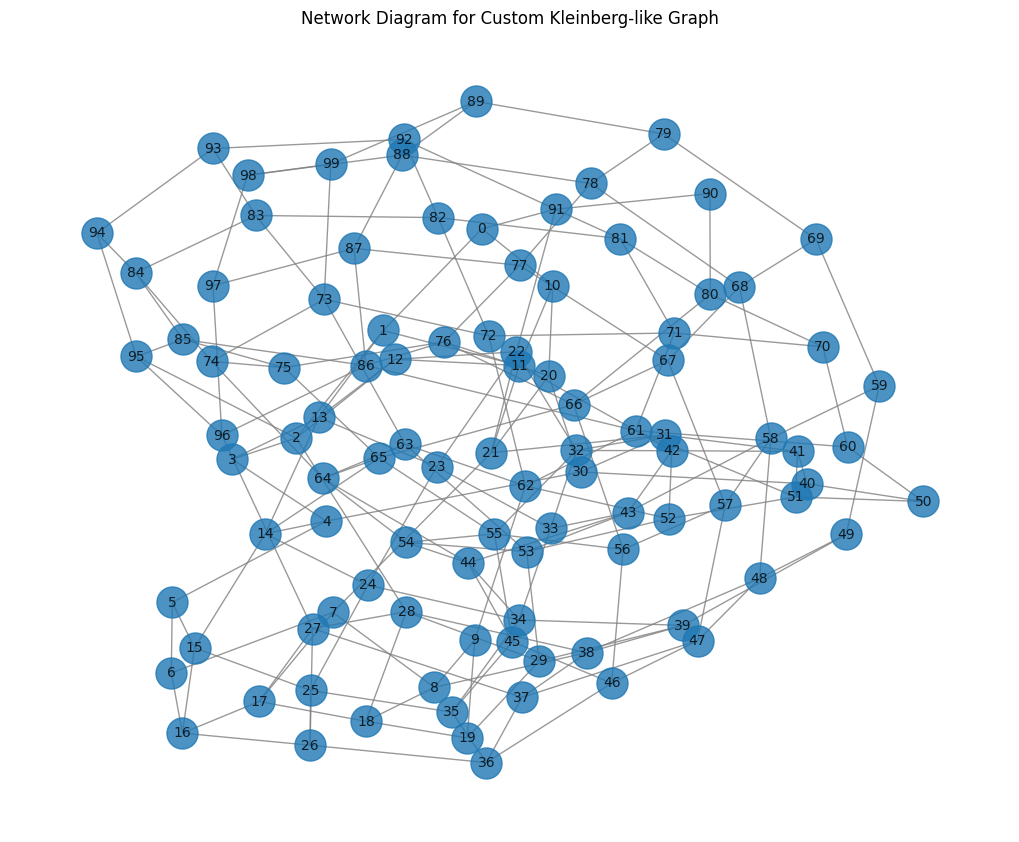

In [ ]:
import random

def create_kleinberg_like_small_world_graph(n_nodes, grid_size, alpha, p_long_range):
    G = nx.Graph()
    nodes = list(range(n_nodes))
    G.add_nodes_from(nodes)
    node_positions = {}
    row, col = 0, 0
    for i in range(n_nodes):
        node_positions[i] = (row, col)
        col += 1
        if col >= grid_size:
            col = 0
            row += 1
            if row >= grid_size:
                 row = grid_size - 1
    for i in nodes:
        for j in nodes:
            if i < j:
                dist = abs(node_positions[i][0] - node_positions[j][0]) + \
                       abs(node_positions[i][1] - node_positions[j][1])
                      #  بخش مربوط به سوال دوم
                if dist == 1:
                     G.add_edge(i, j)
                elif dist in [2, 3] and random.random() < p_long_range:
                     G.add_edge(i, j)
                elif dist > 3 and random.random() < p_long_range:
                     G.add_edge(i, j)
    return G


n_kleinberg_nodes = 100
grid_size_kleinberg = int(np.sqrt(n_kleinberg_nodes))

if grid_size_kleinberg < 1:
    grid_size_kleinberg = 1

G_kleinberg_custom = create_kleinberg_like_small_world_graph(
    n_kleinberg_nodes,
    grid_size_kleinberg,
    alpha=1.0,
    p_long_range=0.005
)

print(f"Created a custom Kleinberg-like small-world graph with {G_kleinberg_custom.number_of_nodes()} nodes and {G_kleinberg_custom.number_of_edges()} edges.")


plt.figure(figsize=(10, 8))
nx.draw(G_kleinberg_custom, with_labels=True, node_size=500, edge_color='gray', alpha=0.8, font_size=10)
plt.title("Network Diagram for Custom Kleinberg-like Graph")
plt.show()

<h4> سوال سوم </h4>

In [ ]:
import random

def greedy_grid_distance_search(graph, start_node, target_node, node_positions):

    if start_node == target_node:
        return [start_node]

    path = [start_node]
    current_node = start_node
    visited = {start_node}

    while current_node != target_node:
        neighbors = list(graph.neighbors(current_node))
        if not neighbors:
            print(f"Search stopped at node {current_node}: No neighbors.")
            return path
        min_dist = float('inf')
        next_node = None
        target_pos = node_positions[target_node]

        for neighbor in neighbors:
            if neighbor not in visited:
                neighbor_pos = node_positions[neighbor]
                dist = abs(neighbor_pos[0] - target_pos[0]) + \
                       abs(neighbor_pos[1] - target_pos[1])
                if dist < min_dist:
                    min_dist = dist
                    next_node = neighbor
        if next_node is None:
            print(f"Search stopped at node {current_node}: Could not find a closer unvisited neighbor.")
            return path
        current_node = next_node
        path.append(current_node)
        visited.add(current_node)
        # این واسه اینه که دیگه قطعا نمیرسه تو یه لوپی گیر کرده مثلا که دیگه از تعداد کل نودها بیشتر شده مسیرمون
        if len(path) > graph.number_of_nodes():
             print("Search stopped: Path length exceeded number of nodes (likely stuck in cycle).")
             return path
    return path

all_nodes = list(G_kleinberg_custom.nodes())
start_node_example = random.choice(all_nodes)
target_node_example = random.choice(all_nodes)
n_kleinberg_nodes_example = G_kleinberg_custom.number_of_nodes()
grid_size_kleinberg_example = int(np.sqrt(n_kleinberg_nodes_example))
node_positions_example = {}
row, col = 0, 0
for i in range(n_kleinberg_nodes_example):
    node_positions_example[i] = (row, col)
    col += 1
    if col >= grid_size_kleinberg_example:
        col = 0
        row += 1
print(f"\nStarting greedy search from node {start_node_example} to {target_node_example}")
search_path = greedy_grid_distance_search(
    G_kleinberg_custom,
    start_node_example,
    target_node_example,
    node_positions_example
)
if search_path:
    print(f"Search Path: {search_path}")
    print(f"Path Length: {len(search_path) - 1 if len(search_path) > 0 else 0}")
    if search_path[-1] == target_node_example:
        print("Target node reached!")
    else:
        print("Target node not reached with greedy search.")
else:
    print("Search failed or target is start node.")


Starting greedy search from node 45 to 82
Search Path: [45, 44, 64, 63, 62, 72, 82]
Path Length: 6
Target node reached!


<h4> سوال چهارم </h4>

In [ ]:
import time
import random


all_nodes = list(G_kleinberg_custom.nodes())
n_nodes = G_kleinberg_custom.number_of_nodes()
# منطقا ما باید چند بار اجرا کنیم تا میانگین بدست بیاد دیگه حالا شاید 1000 عدد زیادی بود میشه کمترش کرد ولی خب هرچی بیشتر دقت هم بیشتر دیگه
num_simulations = 1000
total_steps = 0
successful_searches = 0
total_time = 0
successful_path_lengths = []
print(f"\nRunning {num_simulations} greedy searches...")
for _ in range(num_simulations):
    start_node_example = random.choice(all_nodes)
    target_node_example = random.choice(all_nodes)
    while start_node_example == target_node_example:
         target_node_example = random.choice(all_nodes)
    start_time = time.time()
    search_path = greedy_grid_distance_search(
        G_kleinberg_custom,
        start_node_example,
        target_node_example,
        node_positions_example
    )
    end_time = time.time()
    total_time += (end_time - start_time)
    if search_path is not None:
        successful_searches += 1
        path_length = len(search_path) - 1
        total_steps += path_length
        successful_path_lengths.append(path_length)

        # اینجا هم برا محاسبه مقادیره چیز خاصی نیس
average_steps = total_steps / successful_searches if successful_searches > 0 else 0
success_rate = (successful_searches / num_simulations) * 100
average_time = total_time / num_simulations if num_simulations > 0 else 0
print("\n--- Greedy Search Results ---")
print(f"Total simulations run: {num_simulations}")
print(f"Successful searches: {successful_searches}")
print(f"Success Rate: {success_rate:.2f}%")
print(f"Average steps in successful searches: {average_steps:.2f}")
print(f"Average time per search: {average_time:.6f} seconds")


Running 1000 greedy searches...

--- Greedy Search Results ---
Total simulations run: 1000
Successful searches: 1000
Success Rate: 100.00%
Average steps in successful searches: 5.33
Average time per search: 0.000013 seconds


####سوال پنجم


<div dir="rtl" style="text-align: right;">

### تحلیل رابطه بین لینک‌های دوربرد و کارایی جستجوی حریصانه (بر اساس پیاده‌سازی فعلی)

لینک های دوربرد اولا برای نود های با فاصله بیش از 1 اضافه میشن و با یه احتمالی که تو کد هم اون احتمال رو داریم و فاصله 0 و 1 که میشه خودش و همسایه هاش پس میمونه فواصل 2 و 3 طبق خواسته سوال

برای تحلیل رابطه بین لینک‌های دوربرد و کارایی جستجو، می‌تونیم مراحل زیر رو دنبال کنیم:


1.  **آزمایش با مقادیر مختلف `p_long_range`:** مثلا تابع create_kleinberg_like_small_world_graph رو با مقادیر مختلف p_long_range صدا زدیم که تعداد لینک های دوربرد مختلف رو مشاهده کنیم


2.  **اجرای تحلیل جستجو برای هر گراف:** حالا بعد از اجرای تابع با مقادیر احتمال ساخت لینک دوربرد مختلف جستجوی حریصانه انجام میشه  که میانگین گام ها و درصد موفقیت در اون سلول کد پیدا میشه


3.  **مقایسه نتایج:** نتایج (میانگین گام‌ها و درصد موفقیت) را برای هر مقدار p_long_range که آزمایش کردیم، ثبت و مقایسه میکنیم.

**انتظار بر اساس تئوری کلاینبرگ:**

تئوری اصلی کلاینبرگ (برای جستجوی حریصانه در گرید ۲ بعدی) پیش‌بینی میکنه که کارایی جستجوی حریصانه (که به صورت لگاریتمی با تعداد گره‌ها مقیاس می‌شود) به نحوه توزیع لینک‌های دوربرد بستگی دارد. به طور خاص، اگر احتمال اضافه شدن یک لینک دوربرد بین دو گره با فاصله گرید d متناسب با d^(-α) باشد:

*   اگر `α` نزدیک به بعد گرید باشد (برای گرید ۲ بعدی، α ≈ 2)، جستجوی حریصانه بسیار کارآمد است.
*   اگر `α < 2` باشد (لینک‌های دوربرد بیش از حد به گره‌های دور اضافه می‌شوند)، جستجوی حریصانه ممکن است "میانبرهای" زیادی پیدا کند اما سردرگم شده و کارایی بهینه را نداشته باشد.
*   اگر `α > 2` باشد (لینک‌های دوربرد بیشتر به همسایگان نزدیک اضافه می‌شوند)، گراف بیشتر شبیه به یک گرید می‌شود و جستجوی حریصانه نمی‌تواند به سرعت به نقاط دورتر برسد و کارایی پایین می‌آید.

**تفسیر نتایج در پیاده‌سازی فعلی:**

در این پیاده سازی که کردیم اصن کاری به α نداریم و ما با p_long_range کار داریم و تغییرش میدیم که لینک دوربرد بسازه و گراف لینک دوربرد بیشتری پیدا میکنه


با آزمایش مقادیر مختلف برای p_long_range و مشاهده نتایج جستجوی حریصانه:

*   **افزایش `p_long_range`:**
انتظار می‌رود با افزایش p_long_range تعداد لینک‌های دوربرد در گراف افزایش یابد و میانگین گام های لازم برای رسیدن  برای رسیدن به نود تارگت کاهش بیابه و در نتیجه جست و جوی موفق احتمالش بالا بره


*   **رابطه با تئوری کلاینبرگ:**
مدل ما که فقط بر اساس کلاینبرگ هست نشون دهنده قابل سرچ بودن در صورت تغییر تعداد نود های دوربرد هست و کارایی جست و جوی حریصانه رو بالاتر میبرع  و نشون میده نه تنها این میانبرهای تصادفی وجودشون مهمه بلکه نحوه توزیع  هم مهمه

با تحلیل نتایج عددی میانگین گام‌ها و درصد موفقیت برای مقادیر مختلف p_long_range می‌توانید ببینید که چگونه افزایش اتصالات دوربر بر توانایی الگوریتم حریصانه برای یافتن مسیرها تأثیر می‌گذارد و این مشاهدات را با پیش‌بینی تئوری کلاینبرگ در مورد اهمیت توزیع لینک‌های دوربرد مقایسه کنید

</div>

<h1> بخش چهارم </h1>

<h4> سوال اول </h4>

<p>انتخاب دو نود رندوم و یافتن کوتاه ترین مسیر بین انها </p>

In [ ]:
import random

all_nodes_facebook = list(G_facebook.nodes())
start_node_fb = random.choice(all_nodes_facebook)
target_node_fb = random.choice(all_nodes_facebook)
while start_node_fb == target_node_fb:
    target_node_fb = random.choice(all_nodes_facebook)
print(f"\nFinding shortest path between node {start_node_fb} and node {target_node_fb} in the Facebook graph.")
try:
    shortest_path_fb = nx.shortest_path(G_facebook, source=start_node_fb, target=target_node_fb)
    shortest_path_length_fb = nx.shortest_path_length(G_facebook, source=start_node_fb, target=target_node_fb)
    print(f"Shortest Path: {shortest_path_fb}")
    print(f"Shortest Path Length: {shortest_path_length_fb}")
except nx.NetworkXNoPath:
    print(f"No path exists between node {start_node_fb} and node {target_node_fb}.")


Finding shortest path between node 492 and node 2761 in the Facebook graph.
Shortest Path: [492, 348, 107, 1684, 2761]
Shortest Path Length: 4


<h4> سوال دوم </h4>

In [ ]:
import collections

def limited_bfs(graph, start_node, target_node, max_depth):
    if start_node == target_node:
        return [start_node]
    queue = collections.deque([(start_node, [start_node])])
    visited = {start_node}
    while queue:
        current_node, path = queue.popleft()
        if len(path) - 1 > max_depth:
            continue
        if current_node == target_node:
            return path
        for neighbor in graph.neighbors(current_node):
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    return None

all_nodes_facebook = list(G_facebook.nodes())
start_node_fb_bfs = random.choice(all_nodes_facebook)
target_node_fb_bfs = random.choice(all_nodes_facebook)
while start_node_fb_bfs == target_node_fb_bfs:
    target_node_fb_bfs = random.choice(all_nodes_facebook)
max_search_depth = 5
print(f"\nPerforming limited BFS from node {start_node_fb_bfs} to node {target_node_fb_bfs} with max depth {max_search_depth}.")
bfs_path = limited_bfs(G_facebook, start_node_fb_bfs, target_node_fb_bfs, max_search_depth)
if bfs_path:
    print(f"Path found by limited BFS: {bfs_path}")
    print(f"Path Length: {len(bfs_path) - 1}")
else:
    print(f"No path found within depth {max_search_depth} between node {start_node_fb_bfs} and node {target_node_fb_bfs}.")


Performing limited BFS from node 442 to node 2475 with max depth 5.
Path found by limited BFS: [442, 563, 1912, 2475]
Path Length: 3


####سوال سوم

Measuring runtime growth of limited BFS with increasing depth...
  Depth 1: Average runtime = 0.000657 seconds (Successful: 1/50)
  Depth 2: Average runtime = 0.002700 seconds (Successful: 6/50)
  Depth 3: Average runtime = 0.009125 seconds (Successful: 23/50)
  Depth 4: Average runtime = 0.010371 seconds (Successful: 43/50)
  Depth 5: Average runtime = 0.010192 seconds (Successful: 50/50)
  Depth 6: Average runtime = 0.010621 seconds (Successful: 50/50)
  Depth 7: Average runtime = 0.007625 seconds (Successful: 50/50)
  Depth 8: Average runtime = 0.009898 seconds (Successful: 50/50)


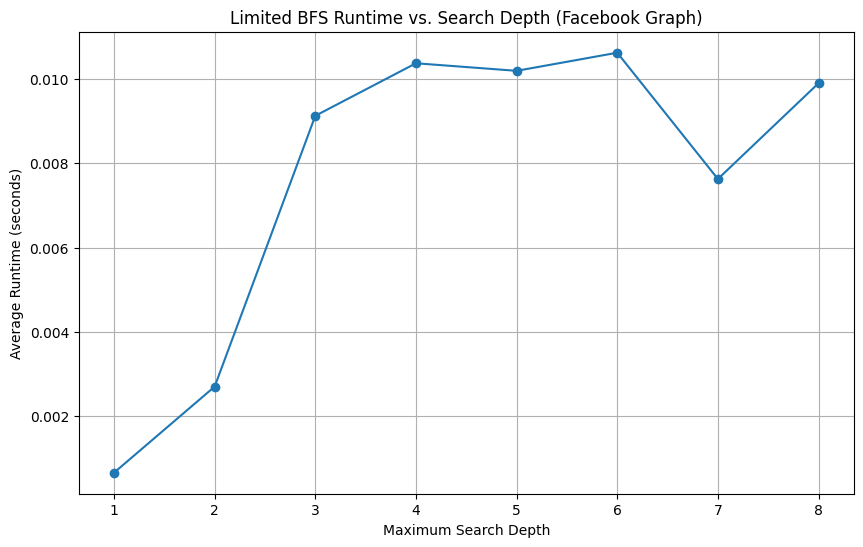


Runtime measurement complete.


In [ ]:
import time
import random

all_nodes_facebook = list(G_facebook.nodes())
num_nodes_facebook = len(all_nodes_facebook)
max_possible_depth = nx.diameter(G_facebook)
depths_to_test = list(range(1, max_possible_depth + 1))
num_runs_per_depth = 50
average_runtimes = []
print("Measuring runtime growth of limited BFS with increasing depth...")
for depth in depths_to_test:
    total_runtime = 0
    successful_runs = 0
    for _ in range(num_runs_per_depth):
        start_node_fb_bfs = random.choice(all_nodes_facebook)
        target_node_fb_bfs = random.choice(all_nodes_facebook)
        while start_node_fb_bfs == target_node_fb_bfs:
            target_node_fb_bfs = random.choice(all_nodes_facebook)
        start_time = time.time()
        bfs_path = limited_bfs(G_facebook, start_node_fb_bfs, target_node_fb_bfs, depth)
        end_time = time.time()
        total_runtime += (end_time - start_time)
        if bfs_path:
            successful_runs += 1
    avg_runtime = total_runtime / num_runs_per_depth
    average_runtimes.append(avg_runtime)
    print(f"  Depth {depth}: Average runtime = {avg_runtime:.6f} seconds (Successful: {successful_runs}/{num_runs_per_depth})")
plt.figure(figsize=(10, 6))
plt.plot(depths_to_test, average_runtimes, marker='o', linestyle='-')
plt.title("Limited BFS Runtime vs. Search Depth (Facebook Graph)")
plt.xlabel("Maximum Search Depth")
plt.ylabel("Average Runtime (seconds)")
plt.grid(True)
plt.show()
print("\nRuntime measurement complete.")

####سوال چهارم

<div dir="rtl" style="text-align: right;">

### تفسیر نتایج اندازه‌گیری زمان اجرای BFS محدود و ارتباط با ساختار شبکه

پس از اجرای کد اندازه‌گیری زمان اجرا برای BFS محدود با اعماق مختلف در گراف فیس‌بوک، انتظار داریم که موارد زیر مشاهده شود:

1.  رشد زمان اجرا با افزایش عمق:
منطقا با افزایش حداکثر عمق ، زمان اجرا هم افزایش میابه چون الگوریتم  عمق بیشتری رو جست و جو میکنه و گره ها و یال های بیشتری رو میبینن

2.  تأثیر ساختار جهان کوچک (میانگین طول مسیر کوتاه): شبکه فیس‌بوک یک نمونه کلاسیک از شبکه جهان کوچک است که با میانگین طول مسیر بسیار کوتاه مشخص می‌شود (حدود ۳.۷ گام در تحلیل‌های قبلی یعنی سوال اول بخش  دوم). این ویژگی به این معنی است که حتی در یک شبکه بزرگ میشه به سرعت (در چند گام) از یک گره به گره‌ای دیگر رسید.  در نتایج BFS محدود میشه این رو دید :
    *   حتی با عمق‌های کم (مثلاً ۳ یا ۴)، درصد موفقیت جستجو به سرعت بالا می‌رود. این یعنی این که خیلی از جفت گره‌های تصادفی در شبکه فیس‌بوک توسط BFS در عمق‌های کم قابل پیدایش هستن که مستقیم به خاصیت میانگین طول مسیر کوتاه ربط پیدا میکنه
    *   پس از رسیدن به یک عمق خاص (نزدیک به میانگین طول مسیر شبکه)، افزایش بیشتر عمق ممکن است افزایش زمان اجرا را ادامه دهد (زیرا فضای جستجو بزرگتر می‌شود)، اما ممکن است افزایش قابل توجهی در درصد موفقیت جستجو ایجاد نکند، زیرا اکثر مسیرهای کوتاه قبلاً یافت شده‌اند.

بعد از اینکه به یه عمقی رسیدیم که نزدیک میانگین طول مسیر هستش افزایش عمق باعث افزایش بیهوده زمان اجرا میشع چون فضای جست و جو بزرگتر میشه ولی موفقیت رو خیلی افزایش نمیده چون بیشتر مسیرهای کوتاه قبلا پیدا شدند


3.  تأثیر توزیع درجه : شبکه فیس‌بوک توزیع درجه سنگین-دم دارد، یعنی این که تعداد کمی از کاربران با تعداد زیادی دوست در شبکه وجود دارن این هاب‌ها نقش مهمی در کاهش میانگین طول مسیر دارند
    *   در BFS محدود، باز کردن یک گره هاب در اوایل جستجو میتونه به سرعت فضای قابل دسترس را افزایش بده و به گره‌های دورتر متصل بشه و مسیر کوتاه تر هم راحت تر پیدا بشه
    *   جست و جو در همسایگی یک گره هاب  بسیار پرهزینه هست چون تعداد یال‌های زیادی برای کاوش وجود دارن
پس وجود هاب‌ها می‌تواند هم به کارآمدی جست و جو از طریق میانبرهای ایجاد شده و هم به افزایش پیچیدگی محلی در اطراف خود هاب‌ها ختم بشه

ارتباط کلی بین ساختار شبکه و پیچیدگی جستجو:

*   شبکه‌های متراکم‌تر و با میانگین درجه بالاتر: در کل در شبکه‌های متراکم‌تر BFS گره‌های بیشتری را در هر سطح از عمق بازدید می‌کند که باعث میشه  زمان اجرا سریع تر رشد کنه چون  افزایش عمق داریم
*   شبکه‌های جهان کوچک (میانگین طول مسیر کوتاه و خوشه‌بندی بالا):
    *   میانگین طول مسیر کوتاه: این ویژگی یعنی این که هدف در اعماق کمتری قابل دسترسی هستض که به BFS اجازه میده تا اغلب در عمق‌های کمتری به هدف برسد و از کاوش کل شبکه جلوگیری کنه این یک عامل کلیدی در کارآمدی جستجو در شبکه‌های بزرگ جهان کوچک هست
    *   خوشه‌بندی بالا: خوشه‌بندی بالا نشان‌ دهنده وجود ساختارهای محلی متراکم است BFS در داخل این خوشه‌ها به سرعت گره‌های همسایه نزدیک را پیدا میکنه هرچند خوشه‌بندی به تنهایی تضمین‌ کننده میانبرهای جهانی نیس ولی با استفاده از یال‌های دوربرد که خاصیت جهان کوچک را تکمیل می‌کنن به کارآمدی کلی جستجو کمک می‌کنه
*   شبکه‌های مقیاس-آزاد (توزیع درجه سنگین-دم و هاب‌ها): وجود هاب‌ها می‌تواند مسیرهای کوتاهی را فراهم کند که BFS میتونه آن‌ها را پیدا کند ولی همانطور که گفته شد کاوش همسایگی هاب‌ها میتونه زمان‌بر باشه پیچیدگی جستجو در شبکه‌های مقیاس-آزاد تحت تأثیر تعامل بین کاوش در همسایگی هاب‌ها و استفاده از میانبرهای ایجاد شده توسط آن‌ها قرار داره

در اخر هم بگیم که نتایج اندازه‌گیری زمان اجرای BFS محدود در گراف فیس‌بوک باید نشان دهد که به لطف ساختار جهان کوچک این شبکه حتی در یک گراف بزرگ مسیرها اغلب در عمق‌های کم یافت میشن و زمان اجرا به سرعت برای رسیدن به این اعماق افزایش می‌یابه ولی بعدش  ممکنه رشدش به دلیل یافتن مسیر های کوتاه در اول جست و جو کندتر بشه
 این یعنی قابل جستجو بودن این شبکه‌ها برای الگوریتم‌های محلی مانند BFS است.
</div>

#بخش پنجم

####سوال اول

<div dir="rtl" style="text-align: right;">

شبکه‌های واقعی مانند شبکه‌های اجتماعی، شبکه‌های همکاری علمی یا شبکه‌های عصبی مغز، به طور همزمان دو ویژگی ظاهراً متناقض دارند: خوشه‌بندی بالا و میانگین طول مسیر کوتاه (خاصیت جهان کوچک). خوشه‌بندی بالا به این معنی است که اگر گره A با B و C در ارتباط باشد، احتمال زیادی وجود دارد که B و C نیز با هم در ارتباط باشند؛ این نشان‌دهنده وجود ساختارهای محلی و گروه‌های متراکم است. از طرف دیگر، میانگین طول مسیر کوتاه نشان می‌دهد که میانگین تعداد گام‌های لازم برای رفتن از هر گرهی به هر گره دیگر در کل شبکه کم است، حتی در شبکه‌های بسیار بزرگ.

ترکیب این دو ویژگی به لطف وجود تعداد نسبتاً کمی "یال دوربرد" یا "میانبر" در کنار تعداد زیادی "یال محلی" اتفاق می‌افتد. یال‌های محلی باعث ایجاد خوشه‌های متراکم و همسایگی‌های نزدیک با خوشه‌بندی بالا می‌شوند. در حالی که بیشتر ارتباطات در درون این خوشه‌ها رخ می‌دهد، تعداد کمی یال که به صورت تصادفی یا هدفمند بین گره‌های دور از هم در خوشه‌های مختلف ایجاد می‌شوند، به عنوان میانبر عمل می‌کنند. این میانبرها به سرعت کل شبکه را به هم متصل کرده و میانگین طول مسیر را به شدت کاهش می‌دهند، بدون اینکه ساختار خوشه‌بندی محلی را به طور کامل از بین ببرند. این ترکیب از ساختار محلی متراکم و میانبرهای جهانی همان چیزی است که به شبکه‌های واقعی هم خوشه‌بندی بالا و هم قابلیت جستجوی بالا (یعنی امکان یافتن مسیرهای کوتاه به صورت کارآمد) را می‌دهد.

</div>

####سوال دوم


<div dir="rtl" style="text-align: right;">


مدل Watts-Strogatz در شبیه‌سازی ساختار شبکه‌های واقعی تا حد زیادی موفق عمل می‌کند، به ویژه در بازتولید همزمان دو ویژگی کلیدی: **میانگین طول مسیر کوتاه** و **ضریب خوشه‌بندی بالا**. این مدل با تنظیم پارامتر بازپیوند (`p`) می‌تواند طیفی از شبکه‌ها را تولید کند که از شبکه منظم با خوشه‌بندی بالا و طول مسیر بلند شروع شده و با افزایش `p` به سرعت به شبکه‌های جهان کوچک با خوشه‌بندی بالا و طول مسیر کوتاه تبدیل می‌شود و در نهایت (برای `p=1`) به یک شبکه تصادفی با خوشه‌بندی پایین و طول مسیر کوتاه می‌رسد. این توانایی در نمایش خاصیت "جهان کوچک" نقطه قوت اصلی این مدل در مقایسه با مدل‌های کاملاً تصادفی مانند Erdos-Rényi است.

با این حال، مدل Watts-Strogatz در بازتولید یکی دیگر از ویژگی‌های مهم بسیاری از شبکه‌های واقعی، یعنی **توزیع درجه سنگین-دم (Heavy-tailed)** یا **قانون توان (Scale-free)**، محدودیت دارد. شبکه‌های Watts-Strogatz، به خصوص برای مقادیر کوچک `p`، تمایل به داشتن توزیع درجه‌ای با قله تیز در اطراف میانگین درجه دارند (مشابه توزیع پواسون در شبکه‌های تصادفی برای p بزرگ). این بدان معنی است که مدل Watts-Strogatz نمی‌تواند وجود "هاب‌های" پرارتباطی که در شبکه‌های اجتماعی، شبکه‌های وب و بسیاری از شبکه‌های بیولوژیکی دیده می‌شوند را به درستی شبیه‌سازی کند. بنابراین، در حالی که این مدل در نمایش ویژگی‌های جهان کوچک موفق است، برای شبکه‌هایی که ساختار مقیاس-آزاد دارند، مدل‌های دیگری مانند مدل Barabási-Albert ممکن است مناسب‌تر باشند.
</div>

####سوال سوم

<div dir="rtl" style="text-align: right;">


مدل کلاینبرگ (Kleinberg's model)، پدیده جستجوی اجتماعی را بهتر از مدل‌های ساده‌تر مانند Watts-Strogatz توضیح می‌دهد، زیرا نه تنها وجود "میانبرهای" تصادفی را در نظر می‌گیرد، بلکه به نحوه **توزیع این میانبرها بر اساس فاصله جغرافیایی یا اجتماعی** اهمیت می‌دهد. در مدل کلاینبرگ، احتمال وجود یک یال دوربرد بین دو گره با فاصله `d`، متناسب با `d^-α` است. این ساختار باعث می‌شود که گره‌های نزدیک به هم احتمال بیشتری برای اتصال داشته باشند (لینک‌های محلی که خوشه‌بندی را ایجاد می‌کنند)، در حالی که احتمال کمتری برای اتصال به گره‌های بسیار دور وجود دارد، اما این احتمال به گونه‌ای کاهش می‌یابد که امکان جستجوی کارآمد محلی را فراهم می‌کند.

نکته کلیدی مدل کلاینبرگ این است که برای مقادیر خاصی از پارامتر `α` (به خصوص `α` نزدیک به بعد فضای زیرین، مثلاً `α ≈ 2` برای گرید ۲ بعدی)، یک الگوریتم جستجوی حریصانه محلی (که همیشه به نزدیک‌ترین گره از نظر فاصله جغرافیایی یا اجتماعی به هدف نهایی می‌رود) می‌تواند هدف را در تعداد گام‌هایی که به صورت لگاریتمی با اندازه شبکه مقیاس می‌شود، پیدا کند. این "قابل جستجو بودن" (searchability) ویژگی مهمی از شبکه‌های اجتماعی واقعی است که مدل کلاینبرگ آن را با دقت بیشتری نسبت به مدل‌هایی که میانبرهای کاملاً تصادفی ایجاد می‌کنند (مانند Watts-Strogatz برای `p=1`) توضیح می‌دهد. در شبکه‌های کاملاً تصادفی، میانبرهای زیادی وجود دارد، اما یافتن میانبر مناسب برای رسیدن به یک هدف خاص با استفاده از اطلاعات محلی دشوار است. مدل کلاینبرگ نشان می‌دهد که یک ساختار سلسله‌مراتبی یا مبتنی بر فاصله در توزیع میانبرها برای جستجوی کارآمد حیاتی است.

<div>

####سوال چهارم

<div dir="rtl" style="text-align: right;">

پیچیدگی زمانی الگوریتم‌های جستجو در شبکه به شدت به ساختار آن وابسته است. در شبکه‌های متراکم‌تر، الگوریتم‌هایی مانند BFS که به صورت لایه به لایه شبکه را کاوش می‌کنند، ممکن است تعداد بیشتری گره و یال را در هر مرحله بررسی کنند که منجر به رشد سریع‌تر زمان اجرا با افزایش عمق جستجو می‌شود. شبکه‌های با میانگین طول مسیر کوتاه، مانند شبکه‌های جهان کوچک، به الگوریتم‌های جستجو اجازه می‌دهند تا اغلب هدف را در عمق‌های کمتری پیدا کنند. این به طور قابل توجهی پیچیدگی زمانی را کاهش می‌دهد، زیرا جستجو نیازی به کاوش بخش‌های دوردست شبکه ندارد. از سوی دیگر، شبکه‌های با توزیع درجه سنگین-دم و وجود "هاب‌ها" می‌توانند مسیرهای بسیار کوتاهی فراهم کنند که برای الگوریتم‌های جستجو مفید است، اما کاوش همسایگی پرارتباط هاب‌ها نیز می‌تواند هزینه محاسباتی بالایی داشته باشد. در مجموع، ویژگی‌هایی مانند تراکم، میانگین طول مسیر و توزیع درجه مستقیماً بر تعداد گره‌ها و یال‌هایی که یک الگوریتم جستجو باید بازدید کند، تأثیر می‌گذارند و در نتیجه پیچیدگی زمانی آن را تعیین می‌کنند.

</div>